In [1]:
# ==========================================
# USED CAR PRICE PREDICTION
# Notebook 01 : Dataset Understanding
# Course: Intelligent AI and Data Engineering
# ==========================================

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [3]:
# Load dataset

df = pd.read_csv("../data/raw/used_cars.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [4]:
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [5]:
df.tail()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
4004,Bentley,Continental GT Speed,2023,714 mi.,Gasoline,6.0L W12 48V PDI DOHC Twin Turbo,8-Speed Automatic with Auto-Shift,C / C,Hotspur,None reported,Yes,"$349,950"
4005,Audi,S4 3.0T Premium Plus,2022,"10,900 mi.",Gasoline,349.0HP 3.0L V6 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,None reported,Yes,"$53,900"
4006,Porsche,Taycan,2022,"2,116 mi.",NaN,Electric,Automatic,Black,Black,None reported,NaN,"$90,998"
4007,Ford,F-150 Raptor,2020,"33,000 mi.",Gasoline,450.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,A/T,Blue,Black,None reported,Yes,"$62,999"
4008,BMW,X3 xDrive30i,2020,"43,000 mi.",Gasoline,248.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,A/T,Gray,Brown,At least 1 accident or damage reported,Yes,"$40,000"


In [6]:
print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

Number of Rows : 4009
Number of Columns : 12


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB


In [8]:
df.dtypes

brand           object
model           object
model_year       int64
milage          object
fuel_type       object
engine          object
transmission    object
ext_col         object
int_col         object
accident        object
clean_title     object
price           object
dtype: object

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
model_year,4009.0,2015.51559,6.104816,1974.0,2012.0,2017.0,2020.0,2024.0


In [10]:
df.describe(include="object").T

,count,unique,top,freq
brand,4009,57,Ford,386
model,4009,1898,M3 Base,30
milage,4009,2818,"110,000 mi.",16
fuel_type,3839,7,Gasoline,3309
engine,4009,1146,2.0L I4 16V GDI DOHC Turbo,52
transmission,4009,62,A/T,1037
ext_col,4009,319,Black,905
int_col,4009,156,Black,2025
accident,3896,2,None reported,2910
clean_title,3413,1,Yes,3413


In [11]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum()/len(df))*100
})
missing.sort_values("Percentage", ascending=False)

,Missing Values,Percentage
clean_title,596,14.866550
fuel_type,170,4.240459
accident,113,2.818658
brand,0,0.000000
milage,0,0.000000
model_year,0,0.000000
model,0,0.000000
engine,0,0.000000
ext_col,0,0.000000
transmission,0,0.000000


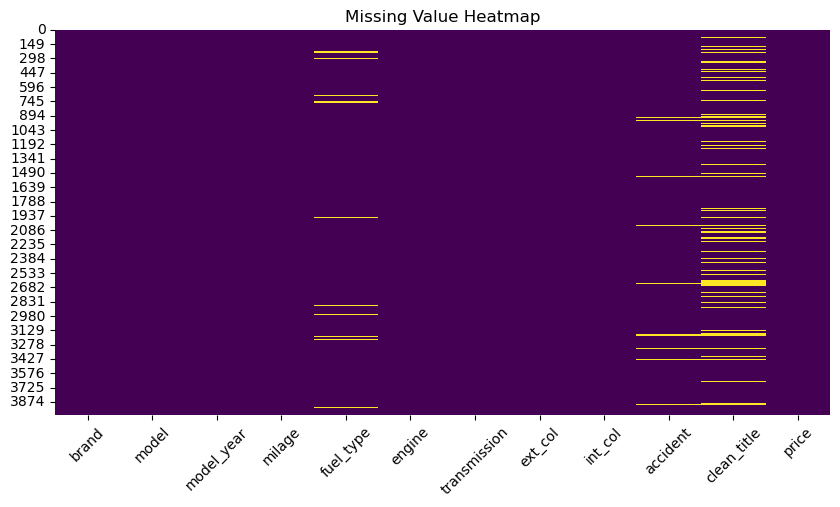

In [16]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(),
            cbar=False,
            cmap="viridis")
plt.title("Missing Value Heatmap")
plt.xticks(rotation=45)
plt.show()

In [13]:
duplicates = df.duplicated().sum()

print("Duplicate Records :", duplicates)

Duplicate Records : 0


In [14]:
df.nunique().sort_values(ascending=False)

milage          2818
model           1898
price           1569
engine          1146
ext_col          319
int_col          156
transmission      62
brand             57
model_year        34
fuel_type          7
accident           2
clean_title        1
dtype: int64

In [15]:
for col in df.columns:
    print("="*60)
    print(col)
    print(df[col].unique()[:10])

brand
['Ford' 'Hyundai' 'Lexus' 'INFINITI' 'Audi' 'Acura' 'BMW' 'Tesla' 'Land'
 'Aston']
model
['Utility Police Interceptor Base' 'Palisade SEL' 'RX 350 RX 350'
 'Q50 Hybrid Sport' 'Q3 45 S line Premium Plus' 'ILX 2.4L'
 'S3 2.0T Premium Plus' '740 iL' 'RC 350 F Sport'
 'Model X Long Range Plus']
model_year
[2013 2021 2022 2015 2016 2017 2001 2020 2019 2003]
milage
['51,000 mi.' '34,742 mi.' '22,372 mi.' '88,900 mi.' '9,835 mi.'
 '136,397 mi.' '84,000 mi.' '242,000 mi.' '23,436 mi.' '34,000 mi.']
fuel_type
['E85 Flex Fuel' 'Gasoline' 'Hybrid' nan 'Diesel' 'Plug-In Hybrid' '–'
 'not supported']
engine
['300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capability'
 '3.8L V6 24V GDI DOHC' '3.5 Liter DOHC'
 '354.0HP 3.5L V6 Cylinder Engine Gas/Electric Hybrid'
 '2.0L I4 16V GDI DOHC Turbo' '2.4 Liter'
 '292.0HP 2.0L 4 Cylinder Engine Gasoline Fuel'
 '282.0HP 4.4L 8 Cylinder Engine Gasoline Fuel'
 '311.0HP 3.5L V6 Cylinder Engine Gasoline Fuel'
 '534.0HP Electric Motor Electric Fuel System']
trans

## Business Problem

The price of a used car depends on many factors such as:

- Brand
- Model
- Model Year
- Mileage
- int-col
- ext-col
- Engine
- Fuel Type
- Transmission
- Accident History
- clean-title

Buyers and sellers often struggle to estimate a fair market value.
The objective of this project is to build a Machine Learning Regression model that predicts the selling price of a used car accurately.

## Target Variable

The target variable is:

**price**

It represents the selling price of the used vehicle.

## Why is this a Regression Problem?

Regression is used when the target variable is continuous.

The selling price of a used car can take any numerical value such as:

$15,000

$23,500

$48,999

Since the target variable is numeric and continuous, this is a supervised Machine Learning Regression problem.

## Initial Observations

- Dataset contains 4,009 records.
- Dataset has 12 variables.
- Target variable is **price**.
- Most features are categorical.
- Price requires cleaning because it contains currency symbols.
- Mileage also requires numeric conversion if stored as text.
- Missing values are present in some categorical columns.
- There is no duplicate records in a datasets.
- Feature engineering may improve prediction performance.

## Conclusion

The dataset has been successfully explored.

Key findings:

- Regression problem identified.
- Target variable selected.
- Dataset structure understood.
- Missing values identified.
- Data types reviewed.
- Initial quality assessment completed.

The next step is Data Cleaning and Preprocessing to prepare the dataset for machine learning.